**Proszę odkomentować i wykonać poniższą komórkę jeśli używają państwo Colaba lub MyBinder!**

In [1]:
# import os
# if not os.path.exists('utils.py'):
#     !curl -O https://raw.githubusercontent.com/NXTRSS/MachineLearningCourse/main/utils.py

In [2]:
# === Konfiguracja środowiska ===
# W Dockerze/uv pakiety są już zainstalowane — komórka po prostu je zaimportuje
# W Google Colab — zainstaluje brakujące pakiety automatycznie

from utils import ensure_package

ensure_package("pandas")
ensure_package("numpy")
ensure_package("matplotlib")
ensure_package("tensorflow")

In [3]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from utils import display_generated_city, visualize_probabilities, reset_seed

# Stała SEED używana w komórkach które wpływają na powtarzalność treningu
# (random init wag w Task 3, dropout/shuffle w Task 4, sampling w Task 5).
# W tych komórkach na początku jest `reset_seed(SEED)`.
SEED = 42

# Model Języka (Language Model) — generujemy nazwy polskich miast

W tym projekcie zajmiemy się technologią, która jest jednym z głównych komponentów takich modeli jak ChatGPT, Claude czy Gemini — *Language Model* ([Wikipedia](https://en.wikipedia.org/wiki/Language_model)).

W ogromnym uproszczeniu Model Języka **stara się przewidzieć kolejne słowo w danej sekwencji**. Pomyślmy o zdaniu:

***Mamy dzisiaj bardzo słoneczną ...***

Zdecydowana większość z nas zaproponowałaby kończące słowo *pogodę*, być może ktoś zaproponowałby *atmosferę*, ale prawie na pewno nikt nie powiedziałby *krzesło*. Dokładnie taką predykcję wykonują modele jak ChatGPT — szacują **warunkowy rozkład prawdopodobieństwa** kolejnego słowa pod warunkiem dotychczasowej sekwencji. Możemy to zapisać tak:

```
P('pogodę'    | ['Mamy', 'dzisiaj', 'bardzo', 'słoneczną']) = 0.95
P('atmosferę' | ['Mamy', 'dzisiaj', 'bardzo', 'słoneczną']) = 0.03
P('krzesło'   | ['Mamy', 'dzisiaj', 'bardzo', 'słoneczną']) ~ 0
```

Liczby powyżej są oczywiście moim subiektywnym szacunkiem, ale chodzi o relację między nimi. Co ważne: **gdybyśmy zsumowali prawdopodobieństwa po wszystkich słowach w słowniku, otrzymalibyśmy 1**. Model Języka zwraca pełen rozkład — dla każdego słowa w słowniku osobne prawdopodobieństwo.

## Dlaczego pójdziemy o stopień niżej — z poziomu słów na poziom liter

Prawdziwy Language Model trenowany jest na ogromnych korpusach (terabajty tekstu — cała Wikipedia, książki, internet). Nas nie stać na taki trening, więc **zejdziemy o jeden poziom niżej**: zamiast przewidywać kolejne słowo, będziemy przewidywać **kolejną literę**.

Pomyśl ile jest możliwych słów w słowniku (setki tysięcy!) a ile liter (~30). Taka redukcja słownika z setek tysięcy do kilkudziesięciu znaków pozwoli nam zbudować mały, szybki, w pełni działający model na laptopie w kilka minut.

Nasz Language Model będzie modelował "język" **polskich nazw miejscowości**. Po treningu będziemy potrafili **generować nowe (nieistniejące) nazwy polskich miast**, które brzmią wiarygodnie.

## Wczytanie danych

Dane pochodzą z [Wykazu urzędowych nazw miejscowości i ich części](https://dane.gov.pl/pl/dataset/188,wykaz-urzedowych-nazw-miejscowosci-i-ich-czesci) — oficjalnego rejestru polskich miejscowości. Plik CSV zawiera prawie 125 000 wpisów (miasta, wsie, kolonie, przysiółki, części miast itp.) z dodatkowymi informacjami geograficznymi i administracyjnymi.

Nas będzie interesować tylko **jeden konkretny typ miejscowości — miasta** (jest ich około 978, zatem nasz mały zbiór treningowy).

In [4]:
import os

if os.path.exists("PRNG_MIEJSCOWOSCI_05_2021.csv"):
    df_cities = pd.read_table("PRNG_MIEJSCOWOSCI_05_2021.csv", sep=';')
else:
    print("Plik lokalny nie znaleziony — pobieram z GitHub...")
    url = "https://raw.githubusercontent.com/NXTRSS/MachineLearningCourse/main/PRNG_MIEJSCOWOSCI_05_2021.csv"
    df_cities = pd.read_table(url, sep=';')
    print("OK")

df_cities.head()

,Główna nazwa miejscowości,Rodzaj miejscowości,Rozróżniający element,element rodzajowy,dopełniacz,przymiotnik,Województwo,Powiat,Gmina,tytuł dokumentu źródłowego,data dokumentu źródłowego,rodzaj reprezentacji,współrzędne geograficzne,współrzędne prostokątne XY,Historyczna nazwa miejscowości
0,Osiedle Struga,część miasta,Struga,Osiedle,-la -gi,NaN,dolnośląskie,dzierżoniowski,Dzierżoniów-gmina miejska,Mapa topograficzna w skali 1:10 000,NaN,punkt główny,"50°43'04"" 16°39'19""",334530.33 319384.25,NaN
1,Abisynia,część wsi,Abisynia,NaN,-nii,NaN,wielkopolskie,pleszewski,Pleszew-gmina miejsko-wiejska,Mapa topograficzna w skali 1:10 000,NaN,punkt główny,"51°53'14"" 17°49'23""",419019.65 447421.45,NaN
2,Abisynia,przysiółek wsi,Abisynia,NaN,-nii,NaN,lubuskie,strzelecko-drezdenecki,Stare Kurowo-gmina wiejska,Mapa topograficzna w skali 1:10 000,NaN,punkt główny,"52°49'31"" 15°39'10""",274559.8 556336.0,NaN
3,Abisynia,część wsi,Abisynia,NaN,-nii,NaN,wielkopolskie,czarnkowsko-trzcianecki,Drawsko-gmina wiejska,"Wykaz urzędowych nazw miejscowości w Polsce, t...",1982-01-01; 2012-12-13,punkt główny,"52°50'46"" 16°01'59""",300270.01 557521.48,NaN
4,Abisynia,część miasta,Abisynia,NaN,-nii,NaN,opolskie,krapkowicki,Krapkowice-gmina miejsko-wiejska,Mapa topograficzna w skali 1:10 000,NaN,punkt główny,"50°29'50"" 17°58'15""",427022.52 292751.83,NaN


Ile mamy miejscowości każdego typu? Zobaczmy rozkład w kolumnie `Rodzaj miejscowości`:

In [5]:
df_cities['Rodzaj miejscowości'].value_counts()

Rodzaj miejscowości
wieś                      43157
część wsi                 42695
część miasta              10858
przysiółek wsi            10424
osada                      5069
kolonia wsi                3996
osada leśna                2263
kolonia                    2149
leśniczówka                1235
miasto                      978
osada wsi                   763
część kolonii               272
osada leśna wsi             239
przysiółek                  130
część osady                  81
przysiółek osady             73
przysiółek kolonii           69
schronisko turystyczne       48
kolonia kolonii              28
kolonia osady                15
osada osady                   8
osiedle                       5
osiedle wsi                   5
osada kolonii                 4
Name: count, dtype: int64

Widać, że dominują wsie i części wsi. **Miast jest tylko 978** — to nasz zbiór treningowy. Niewiele jak na uczenie sieci neuronowej, ale wystarczy do pokazania mechanizmu.

### Zadanie 1 — wybierz miasta

Z DataFrame `df_cities` wybierz tylko te wiersze, gdzie kolumna `Rodzaj miejscowości` zawiera wartość `'miasto'`. Z tego podzbioru wyciągnij kolumnę `Główna nazwa miejscowości` jako **listę Pythonową** i zapisz do zmiennej `list_of_cities`.

In [6]:
try:

    list_of_cities = ...  # Tutaj wpisz swój kod

    print(list_of_cities[:10])
except TypeError:
    print('Proszę uzupełnić rozwiązanie powyżej')

Proszę uzupełnić rozwiązanie powyżej


###### <span style="color: #c17f24;">💡 Podpowiedź</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

Filtrowanie wierszy w DataFrame: `df[df['kolumna'] == 'wartość']` zwraca podzbiór wierszy spełniających warunek.

Wybór jednej kolumny: `df['kolumna']` (zwraca Series). Konwersja Series na zwykłą listę Pythonową: metoda `.tolist()`.

###### <span style="color: #5a8a6a;">✅ Rozwiązanie</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

In [7]:
list_of_cities = df_cities[df_cities['Rodzaj miejscowości'] == 'miasto']['Główna nazwa miejscowości'].tolist()

list_of_cities[:10]

['Aleksandrów Kujawski',
 'Aleksandrów Łódzki',
 'Alwernia',
 'Andrychów',
 'Annopol',
 'Augustów',
 'Babimost',
 'Baborów',
 'Baranów Sandomierski',
 'Barcin']

###### 

## Tokeny początku i końca sekwencji

Model będzie generował nazwy znak po znaku. Żeby wiedział gdzie nazwa się zaczyna i gdzie kończy, dodamy dwa **specjalne tokeny**:

- `%` — *start of sentence* (sos): "tu zaczyna się nazwa"
- `!` — *end of sentence* (eos): "tu nazwa się kończy"

Standardowo używa się tagów typu `<sos>` i `<eos>`, ale ponieważ nasz model jest **oparty na pojedynczych literach**, wygodniej jest użyć pojedynczych znaków, które normalnie nie występują w nazwach miast. Po dodaniu tokenów `Wrocław` zamieni się w `%Wrocław!`.

Po co to? **Token `%` pozwoli modelowi wystartować generację bez kontekstu**, a **token `!` modelu nauczy się przewidywać tam, gdzie nazwa powinna się skończyć** — dzięki temu w fazie generowania model sam zdecyduje kiedy przerwać, zamiast generować w nieskończoność.

### Zadanie 2 — dodaj tokeny do każdej nazwy

Dla każdej nazwy w `list_of_cities` utwórz nowy string poprzez dodanie `%` na początku i `!` na końcu. Wynik zapisz do listy `city_list`. Polecam użyć *list comprehension*.

In [8]:
try:

    city_list = ...  # Tutaj wpisz swój kod

    print(city_list[:10])
except TypeError:
    print('Proszę uzupełnić rozwiązanie powyżej')

Proszę uzupełnić rozwiązanie powyżej


###### <span style="color: #c17f24;">💡 Podpowiedź</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

Konkatenacja stringów w Pythonie: `'%' + tekst + '!'` daje `'%tekst!'`.

*List comprehension* — wzorzec: `[wyrażenie_dla_x for x in lista]`. Wewnątrz `wyrażenie_dla_x` możesz użyć konkatenacji.

###### <span style="color: #5a8a6a;">✅ Rozwiązanie</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

In [9]:
city_list = ['%' + city + '!' for city in list_of_cities]

city_list[:10]

['%Aleksandrów Kujawski!',
 '%Aleksandrów Łódzki!',
 '%Alwernia!',
 '%Andrychów!',
 '%Annopol!',
 '%Augustów!',
 '%Babimost!',
 '%Baborów!',
 '%Baranów Sandomierski!',
 '%Barcin!']

###### 

## Tokenizacja — zamiana liter na liczby

Sieć neuronowa nie umie pracować z napisami — potrzebuje liczb. Musimy więc każdej literze przypisać unikalny numer (tak zwany *token id*). Tę operację wykonuje **tokenizer**.

W naszym przypadku tokenizer pracuje w trybie `char_level=True` — każda litera (oraz `%` i `!`) dostaje własny numer. Jest jeszcze jeden ważny szczegół: zostawiamy oryginalną wielkość liter (`lower=False`), żeby model nauczył się **prawidłowej kapitalizacji** — przecież polskie miasta piszemy z dużej litery (Warszawa, nie warszawa).

Dodatkowo zostawimy w słowniku numer `0` jako *padding* (o tym za chwilę).

In [10]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Embedding, GRU, Dense
from tensorflow.keras.losses import SparseCategoricalCrossentropy
import tensorflow.keras as keras

In [11]:
# resetujemy filtr aby nie usunął tokenów % i !; nie zmniejszamy liter — model ma się nauczyć poprawnej wielkości
tokenizer = Tokenizer(filters='', lower=False, char_level=True)
tokenizer.fit_on_texts(city_list)

# +1 bo zarezerwujemy indeks 0 dla paddingu
vocab_size = len(tokenizer.word_index) + 1
print(f'Wielkość naszego słownika wynosi: {vocab_size}')

Wielkość naszego słownika wynosi: 63


Słownik (mapa: znak → numer) jest dość duży — to wszystkie litery polskiego alfabetu plus znaki specjalne. Możesz całość zobaczyć wywołując `tokenizer.word_index`. Zerknijmy na pierwszych siedem najczęstszych znaków:

In [12]:
Nth = ['Pierwszy', 'Drugi', 'Trzeci', 'Czwarty', 'Piąty', 'Szósty', 'Siódmy']

for nth, items in zip(Nth, tokenizer.word_index.items()):
    print(f'{nth:8} - {items[0]}:{items[1]}')

Pierwszy - %:1
Drugi    - !:2
Trzeci   - i:3
Czwarty  - o:4
Piąty    - a:5
Szósty   - e:6
Siódmy   - z:7


## Czym jest X i Y w naszym zadaniu?

Wracając do Modelu Języka na poziomie słów: mając zdanie

```
Mamy dzisiaj bardzo słoneczną pogodę
```

trenowalibyśmy model na parze:

```
              X                   ->   Y
Mamy dzisiaj bardzo słoneczną ... -> pogodę
```

Bardzo podobnie chcemy zrobić z naszymi nazwami miast — tylko teraz "tokenem" jest pojedynczy znak. Dla nazwy `%Baborów!` formalnie chcielibyśmy przewidywać:

```
    X     -> Y
%Baborów  -> !            P(! | %Baborów)
%Baboró   -> w            P(w | %Baboró)
%Babor    -> ó            P(ó | %Babor)
%Babo     -> r            P(r | %Babo)
...
```

To wiele osobnych przykładów dla jednej nazwy! Na szczęście **sieci RNN są w stanie zamknąć wszystkie te iteracje w jednym przebiegu** — wystarczy podać jako X i Y następujące parę "przesuniętych o jeden znak":

```
    X      ->     Y
%Baborów   ->  Baborów!
```

Sieć RNN będzie tak "sprytna", że na podstawie takiego X i Y nauczy się po kolei wyznaczać:

1. `P(B | %)`
2. `P(a | %B)`
3. `P(b | %Ba)`
4. `P(o | %Bab)`
5. ...

Jeden przebieg modelu, wiele predykcji — w tym tkwi siła rekurencyjnych sieci neuronowych dla sekwencji.

## Padding — wyrównanie długości sekwencji

Jeszcze jeden techniczny szczegół: nazwy miast mają **różne długości** (`Łódź` ma 4 znaki, `Baranów Sandomierski` ma 20). Sieć neuronowa wolałaby pracować z **macierzą o stałych wymiarach** — tj. wszystkie nazwy w batchu o tej samej długości.

Rozwiązanie: znajdujemy najdłuższą nazwę i krótsze **uzupełniamy zerami** (token o id `0`, którego nie używamy do żadnej litery). To właśnie *padding*.

```
%Babimost!000000000000   <- krótsza, dopełniona zerami
%Baranów Sandomierski!   <- najdłuższa, bez paddingu
```

**Ale uwaga — pojawia się problem.** Krótsze nazwy będą w dużej części złożone z zer. Model uczyłby się "z padding generuj padding" — nie jest to wiedza zła, ale bezużyteczna i sztucznie zaniża błąd treningowy. Dlatego później ustawimy **maskowanie zer** w warstwie Embedding (`mask_zero=True`) — wartości w pozycjach paddingu nie będą wliczane do funkcji straty.

In [13]:
# X to każda nazwa bez ostatniego znaku (czyli %Baborów), Y to ta sama nazwa bez pierwszego znaku (Baborów!)
X_train = [city[:-1] for city in city_list]
y_train = [city[1:] for city in city_list]

print(f'Przykładowe wejście: {X_train[6]}, przykładowe wyjście: {y_train[6]}')

# Zamiana stringów na sekwencje liczb (tokenizacja)
X_train = tokenizer.texts_to_sequences(X_train)
y_train = tokenizer.texts_to_sequences(y_train)

# Padding zerami z prawej strony do długości najdłuższej nazwy
X_train = pad_sequences(X_train, padding='post')
y_train = pad_sequences(y_train, padding='post')

print(f'Po tokenizacji i paddingu — wejście: {X_train[6]}')
print(f'Po tokenizacji i paddingu — wyjście: {y_train[6]}')

Przykładowe wejście: %Babimost, przykładowe wyjście: Babimost!
Po tokenizacji i paddingu — wejście: [ 1 28  5 22  3 26  4 13 21  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
Po tokenizacji i paddingu — wyjście: [28  5 22  3 26  4 13 21  2  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]


In [14]:
X_train.shape

(978, 24)

###### <span style="font-family:Monospace">(978, 24)</span>

Kształt `(978, 24)` oznacza: 978 nazw miast, każda dopełniona do 24 znaków (długość najdłuższej nazwy).

Możesz zauważyć ważną własność tej pary — wyjście Y to wejście X **przesunięte o jeden znak**. To jest serce treningu modelu autoregresyjnego: dla każdej pozycji `i` w sekwencji model uczy się przewidywać znak na pozycji `i+1`.

## Konstrukcja modelu

Teraz najciekawsze — sam model. Zbudujemy klasę `LanguageModel` dziedziczącą po `keras.Model`. Składa się z trzech warstw:

1. **`Embedding`** — zamienia każdy token (numer litery) na **gęsty wektor** o wymiarze 256. Surowy numer (np. `5` dla litery `e`) nie niesie żadnej semantyki — wektor uczonych embeddingów tak. Argument `mask_zero=True` mówi: *ignoruj pozycje z paddingiem (token `0`) podczas obliczania straty*.
2. **`GRU`** — komórka rekurencyjna z 128 jednostkami. Czyta sekwencję wektorów z Embedding po kolei, dla każdej pozycji wypluwa wektor reprezentujący "stan" sieci po przeczytaniu prefixu sekwencji. To jest miejsce, gdzie sieć "rozumie" kontekst. Dodatkowo dodamy **dropout=0.1** dla regularyzacji.
3. **`Dense`** z `softmax` — wyjściowa warstwa pełnopołączona. Z wektora stanu GRU wyznacza **rozkład prawdopodobieństwa** nad całym słownikiem (czyli dla każdej możliwej kolejnej litery).

Dlaczego GRU a nie zwykły perceptron? Bo dla sekwencji potrzebujemy modelu, który **pamięta wcześniejsze elementy** — GRU robi to przez utrzymywanie *hidden state*, który propaguje się przez sekwencję.

Dwie ważne flagi w GRU:

- `return_sequences=True` — chcemy wyjście **dla każdej pozycji** w sekwencji (a nie tylko ostatniej). Bez tego dostalibyśmy jedną predykcję zamiast po jednej dla każdego znaku.
- `return_state=True` — niech GRU zwróci nam też **końcowy hidden state**. Wykorzystamy go później przy generacji nazw — dzięki temu nie będziemy musieli puszczać przez sieć całego promptu od nowa w każdej iteracji.

> *Konkretne wartości (256, 128, dropout=0.1) zostały wybrane na podstawie automatycznego search'u hiperparametrów — testowaliśmy ~30 różnych konfiguracji i ta dała najlepszy balans między jakością a stabilnością treningu.*

### Zadanie 3 — uzupełnij klasę LanguageModel

Uzupełnij metodę `__init__` zgodnie z opisem powyżej. Trzy warstwy: `Embedding`, `GRU`, `Dense`. Pamiętaj o flagach `mask_zero`, `return_sequences`, `return_state` oraz odpowiedniej funkcji aktywacji w warstwie wyjściowej.

In [15]:
reset_seed(SEED)


class LanguageModel(keras.Model):
    def __init__(self):
        super().__init__()

        # warstwa Embedding — zamienia indeksy tokenów na gęste wektory
        # parametry: rozmiar słownika, output_dim=256, maskowanie zer (mask_zero=True)

        self.embedding = ...  # Tutaj wpisz swój kod

        # warstwa GRU — przetwarzanie sekwencyjne, 128 jednostek + dropout=0.1
        # zwraca wyjście dla każdego kroku oraz końcowy stan ukryty

        self.rnn = ...  # Tutaj wpisz swój kod

        # warstwa Dense — predykcja rozkładu nad słownikiem
        # ile wyjść? jaka funkcja aktywacji reprezentuje rozkład prawdopodobieństwa?

        self.fc = ...  # Tutaj wpisz swój kod

    def call(self, inputs, training=False, hidden_state=None, return_state=False):
        """
        inputs        - tensor [batch_size x sequence_length]
        training      - czy model jest w fazie treningu
        hidden_state  - opcjonalny stan początkowy GRU; None = wektor zerowy
        return_state  - czy zwrócić ostatni hidden state oprócz predykcji
        """
        x = self.embedding(inputs, training=training)

        # GRU zwraca dwie rzeczy: sekwencję wyjść i końcowy hidden state
        seq_out, last_hidden_state = self.rnn(x, training=training, initial_state=hidden_state)

        x = self.fc(seq_out)

        if return_state:
            return x, last_hidden_state
        return x


try:
    model = LanguageModel()
    model(X_train)
    model.summary()
except TypeError:
    print('Proszę uzupełnić warstwy w klasie LanguageModel powyżej')

Proszę uzupełnić warstwy w klasie LanguageModel powyżej


###### <span style="color: #c17f24;">💡 Podpowiedź</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

**Embedding:** pierwszy argument to liczba wszystkich możliwych tokenów (mamy zmienną `vocab_size`). Drugi to rozmiar wektora (`output_dim`, u nas 256). Pamiętaj o `mask_zero`.

**GRU:** liczba jednostek 128. Potrzebujesz **dwóch** flag — jednej żeby dostać wyjście dla każdego kroku sekwencji, drugiej żeby dostać dodatkowo ostatni stan ukryty. Dodaj też `dropout=0.1` dla regularyzacji.

**Dense:** liczba wyjść = ile możliwych klas chcemy wypredykować (czyli ile różnych "kolejnych liter" wchodzi w grę). Funkcja aktywacji która zamienia logity w rozkład prawdopodobieństwa to `softmax`.

###### <span style="color: #5a8a6a;">✅ Rozwiązanie</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

In [16]:
reset_seed(SEED)


class LanguageModel(keras.Model):
    def __init__(self):
        super().__init__()

        # L config (best z hyperparam search) — emb=256, gru=128, dropout=0.1 (~172k params)
        self.embedding = Embedding(vocab_size, output_dim=256, mask_zero=True)
        self.rnn = GRU(128, return_sequences=True, return_state=True, dropout=0.1)
        self.fc = Dense(vocab_size, activation='softmax')

    def call(self, inputs, training=False, hidden_state=None, return_state=False):
        x = self.embedding(inputs, training=training)

        # initial_state=None → GRU automatycznie użyje wektora zerowego
        seq_out, last_hidden_state = self.rnn(x, training=training, initial_state=hidden_state)
        x = self.fc(seq_out)

        if return_state:
            return x, last_hidden_state
        return x


model = LanguageModel()
model(X_train)
model.summary()

Model: "language_model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (978, 24, 256)         │        16,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ((978, 24, 128), (978, │       148,224 │
│                                 │ 128))                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (978, 24, 63)          │         8,127 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 172,479 (673.75 KB)

 Trainable params: 172,479 (673.75 KB)

 Non-trainable params: 0 (0.00 B)

###### 

###### <span style="color: #4a7090;">📊 Spodziewany wynik</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

```
Model: "language_model"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (978, 24, 256)         │        16,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ((978, 24, 128), (978, │       147,840 │
│                                 │ 128))                  │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (978, 24, 63)          │         8,127 │
└─────────────────────────────────┴────────────────────────┴───────────────┘
 Total params: 172,095 (672.25 KB)
 Trainable params: 172,095 (672.25 KB)
 Non-trainable params: 0 (0.00 B)
```

Łącznie ~172 tys. parametrów — model nadal mały jak na standardy współczesnego deep learningu (LLM-y mają setki miliardów). **Te wartości pochodzą z Bayesowskiego search'a** — testowaliśmy ~30 różnych konfiguracji i ta okazała się optymalna pod kątem balansu między jakością a powtarzalnością treningu.

###### 

## Trening

Mamy model — czas go nauczyć. Potrzebujemy czterech rzeczy:

- **Funkcji straty (loss)** — mierzy jak bardzo predykcja modelu różni się od prawdy. Dla klasyfikacji wieloklasowej (a tym właśnie jest predykcja kolejnej litery — wybór jednej z ~63 klas) standardowo używamy **Cross-Entropy**. Wariant *Sparse* przyjmuje etykiety jako liczby całkowite (a nie one-hot), co odpowiada naszemu formatowi `y_train`.
- **Optymalizatora** — algorytmu który aktualizuje wagi modelu na podstawie gradientu funkcji straty. Użyjemy **Adam z `learning_rate=0.001`** (klasyczna domyślna wartość).
- **Batch size** — ile próbek na raz przerabiamy podczas jednego kroku treningu. **64** to dobry kompromis między szybkością a stabilnością gradientów.
- **Liczby epok** — ile razy przejdziemy przez cały zbiór treningowy. **80 epok** to wystarczy dla naszego małego zbioru — search z early stoppingiem pokazał że model konwerguje wcześniej.

> *Wszystkie te wartości (lr, batch_size, epochs) wybraliśmy na podstawie hyperparameter search'u.*

### Zadanie 4 — skompiluj i wytrenuj model

Trzy kroki:

1. **`criterion`** — utwórz instancję **Sparse Categorical Cross-Entropy**.
2. **`model.compile(...)`** — przekaż `loss=criterion` oraz `optimizer=Adam(learning_rate=0.001)`.
3. **`history = model.fit(...)`** — przekaż `X_train`, `y_train`, `epochs=80`, `batch_size=64`.

Wynik (`history`) zapisuje stratę z każdej epoki — wykorzystamy to za chwilę do narysowania krzywej uczenia.

In [17]:
reset_seed(SEED)

try:

    # 1) Sparse Categorical Cross-Entropy (klasa, więc instancjuj przez ())
    criterion = ...  # Tutaj wpisz swój kod

    # 2) optymalizator: Adam z learning_rate=0.001
    model.compile(loss=criterion, optimizer=...)  # Tutaj wpisz swój kod

    # 3) trening: X_train, y_train, epochs=80, batch_size=64
    history = model.fit(..., ..., epochs=..., batch_size=...)  # Tutaj wpisz swój kod
except Exception:
    print('Proszę uzupełnić rozwiązanie powyżej')

Proszę uzupełnić rozwiązanie powyżej


###### <span style="color: #c17f24;">💡 Podpowiedź</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

**`criterion`** — w komórce z importami zaimportowaliśmy klasę zaczynającą się od *Sparse* (wariant Cross-Entropy dla całkowitych etykiet, bez one-hot). To jest **klasa**, nie funkcja — pamiętaj o `()` żeby utworzyć instancję.

**`optimizer`** — `keras.optimizers.Adam(learning_rate=0.001)`. Możesz też podać jako string `'adam'`, ale wtedy użyjesz domyślnego learning_rate (też 0.001 — w naszym przypadku to bez różnicy).

**`model.fit(X, Y, epochs=N, batch_size=M)`** — pierwsze dwa argumenty to dane treningowe (`X_train`, `y_train`). Liczba epok = 80, batch_size = 64.

###### <span style="color: #5a8a6a;">✅ Rozwiązanie</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

In [18]:
reset_seed(SEED)

criterion = SparseCategoricalCrossentropy()

# L config — Adam z learning_rate=0.001 (default Adam), batch_size=64
model.compile(loss=criterion, optimizer=keras.optimizers.Adam(learning_rate=0.001))

history = model.fit(X_train, y_train, epochs=80, batch_size=64)

Epoch 1/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - loss: 3.9408
Epoch 2/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 3.3096
Epoch 3/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 2.9769
Epoch 4/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 2.6660
Epoch 5/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - loss: 2.4729
Epoch 6/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 2.3588
Epoch 7/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 2.2827
Epoch 8/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 2.2268
Epoch 9/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 2.1810
Epoch 10/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 2.1413
Epoch 11/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 2.1040
Epoch 12/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 2.0715
Epoch 13/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 2.0400
Epoch 14/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 2.0123
Epoch 15/80
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 1.9848
Epoc

###### 

### Krzywa uczenia

Zobaczmy jak loss zmieniał się przez kolejne epoki — krzywa powinna **opadać i się stabilizować**. Jeśli widzimy nagłe skoki w górę, to znak że coś poszło nie tak. Jeśli krzywa nadal opada gwałtownie na końcu, można dotrenować więcej epok.

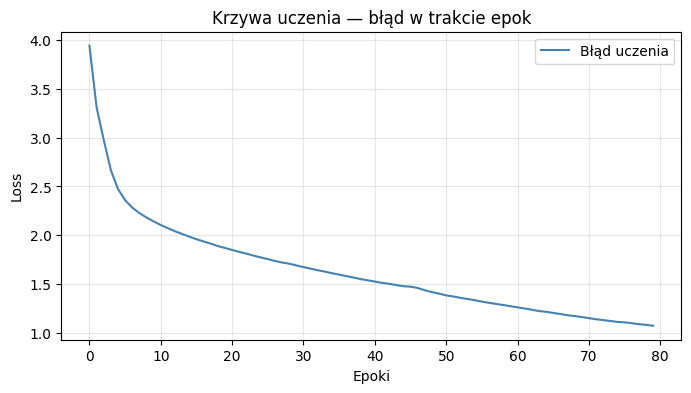

In [19]:
loss = history.history['loss']

plt.figure(figsize=(8, 4))
plt.plot(loss, label='Błąd uczenia', color='steelblue')
plt.xlabel('Epoki')
plt.ylabel('Loss')
plt.title('Krzywa uczenia — błąd w trakcie epok')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Przełączamy seed przed generacją

Trening modelu chcieliśmy mieć **powtarzalny** — dlatego w Task 3 i Task 4 użyliśmy `reset_seed(SEED)` (gdzie `SEED=42`). Każdy student dostanie ten sam model.

Ale przy **generacji nazw** chcemy zróżnicowania — każda sesja powinna dać inne nazwy, w przeciwnym razie demo robi się nudne. Dlatego teraz przełączymy seed na **bieżący czas** (`time.time()`):

In [ ]:
import time

# Trening był deterministyczny (SEED=42), ale generacja powinna dawać różne nazwy
# w każdej sesji — dlatego przełączamy seed na bieżący czas.
reset_seed(int(time.time()))

## Generacja nazw — pierwsza, naiwna wersja

Mamy wytrenowany model — czas go użyć! Pamiętaj że to **model generatywny** — potrafi tworzyć nowe obiekty, których nigdy nie widział w danych treningowych. W naszym przypadku — nowe (potencjalnie nieistniejące) nazwy miast.

Generacja działa tak:

1. Zaczynamy od *prompta* — minimalnie samego tokena `%`. Można też podać kilka pierwszych liter (np. `%Wro` — niech model dokończy nazwę zaczynającą się od "Wro").
2. Puszczamy prompt przez model. Dostajemy rozkład prawdopodobieństwa nad następną literą.
3. **Wybieramy** kolejną literę z tego rozkładu — dwie strategie:
   - **Greedy sampling** — bierzemy literę o najwyższym prawdopodobieństwie. Wynik **deterministyczny**, ale często wpada w pętlę.
   - **Probabilistic sampling** (stochastyczny) — losujemy literę zgodnie z rozkładem. Wynik **różnorodny**, czasem zaskakujący.
4. Doklejamy literę do prompta i wracamy do kroku 2.
5. Stop kiedy model wygeneruje token `!` (albo po 30 znakach — zabezpieczenie).

> *Informacyjnie: poza Greedy i Probabilistic istnieje jeszcze* **Beam search** *— wariant pośredni, śledzący równolegle kilka najprawdopodobniejszych ścieżek. Implementacja dla chętnych.*

Zaczniemy od najprostszego, **nieefektywnego** wariantu: w każdej iteracji puszczamy przez sieć **cały rosnący prompt od nowa**. To marnuje czas (sieć liczy tę samą rzecz wielokrotnie), ale jest najprostsze do zrozumienia.

In [20]:
def sample_model(prompt="%", greedy=False, print_outcome=True, real_cities=None):
    # maksymalnie 30 znaków — zabezpieczenie przed nieskończoną generacją
    for i in range(30):
        # tokenizacja promptu — Keras 3 wymaga tensora/numpy, nie zwykłej listy
        encoded_prompt = tokenizer.texts_to_sequences([prompt])
        encoded_prompt = tf.convert_to_tensor(encoded_prompt)

        # predykcja rozkładu — z całego promptu od nowa (nieoptymalne!)
        output = model.predict(encoded_prompt, verbose=0)

        # interesuje nas rozkład po ostatnim znaku promptu
        last_output = output[0, -1, :]

        if greedy:
            next_char_idx = last_output.argmax()
        else:
            next_char_idx = np.random.choice(np.arange(len(last_output)), p=last_output)

        next_char = tokenizer.index_word[next_char_idx]
        prompt += next_char

        if next_char == '!':
            break

    if print_outcome:
        display_generated_city(prompt, real_cities=real_cities)
    return prompt

In [26]:
# Uruchom kilka razy — za każdym razem dostaniesz inną nazwę (bo sampling stochastyczny).
# Bez `reset_seed` tutaj świadomie — chcemy żeby kolejne wywołania dały różne wyniki.
# Przekazujemy zbiór miast — pod nazwą zobaczysz marker czy istnieje czy jest nowa.
sample_model("%", real_cities=set(list_of_cities))

## 🏘️ **Wygenerowana nazwa miasta:** `Stawisk`

✨ Nowa, **nieistniejąca** nazwa — model ją wymyślił

'%Stawisk!'

## Generacja — wersja zoptymalizowana z hidden state

Powyższa wersja jest poprawna, ale **marnotrawi obliczenia**: dla promptu `%Wroc` puszczamy przez sieć cztery znaki, w następnej iteracji `%Wroca` — pięć znaków, znowu od początku. A przecież sieć już "przerobiła" pierwsze cztery!

Wykorzystajmy właściwości RNN — komórka GRU utrzymuje **hidden state** (pamięć tego co przeczytała). Wystarczy:

1. Pierwsze wywołanie: puszczamy cały prompt, **zapamiętujemy ostatni hidden state**.
2. Wybieramy kolejną literę z rozkładu.
3. Następne wywołanie: do modelu wpychamy **tylko nową literę**, ale **z zachowanym hidden state** z poprzedniego kroku. Sieć działa tak jakbyśmy przetworzyli całą historię — bo hidden state ją pamięta.

To dokładnie ta optymalizacja, którą stosują wielkie LLM-y (tam nazywa się to *KV cache*) — bez tego inferencja byłaby koszmarnie wolna.

Przy okazji dorzucimy **wizualizację rozkładu prawdopodobieństw** — żeby zobaczyć co model "myśli" w każdym kroku.

In [22]:
def sample_model_optimal(prompt='%', greedy=False, print_outcome=True, visuals=False, real_cities=None):
    # zakodowanie pełnego promptu — ten fragment przerabiamy raz
    encoded_prompt = tokenizer.texts_to_sequences([prompt])
    encoded_prompt = tf.convert_to_tensor(encoded_prompt)

    # startujemy bez hidden state — model użyje wektora zer
    hidden_state = None

    for i in range(30):
        # predykcja + zwrot hidden state, który przekażemy w następnej iteracji
        model_out, hidden_state = model(encoded_prompt, return_state=True, hidden_state=hidden_state)

        last_output = model_out[0, -1, :].numpy()

        # najpierw decyzja o kolejnym znaku, dopiero potem wizualizacja —
        # żeby na wykresie móc oznaczyć wybraną literę
        if greedy:
            next_char_idx = last_output.argmax()
        else:
            next_char_idx = np.random.choice(np.arange(len(last_output)), p=last_output)

        if visuals:
            visualize_probabilities(last_output, i, tokenizer, prompt, chosen_idx=next_char_idx, show=False)

        next_char = tokenizer.index_word[next_char_idx]
        prompt += next_char

        # KLUCZOWE: w następnym kroku wpychamy do modelu TYLKO ostatnio wygenerowany znak
        # cała historia siedzi już w hidden_state
        encoded_prompt = tokenizer.texts_to_sequences([next_char])
        encoded_prompt = tf.convert_to_tensor(encoded_prompt)

        if next_char == '!':
            break

    if print_outcome:
        display_generated_city(prompt, real_cities=real_cities)
    if visuals:
        plt.show()
    return prompt

## 🏘️ **Wygenerowana nazwa miasta:** `Praszków`

✨ Nowa, **nieistniejąca** nazwa — model ją wymyślił

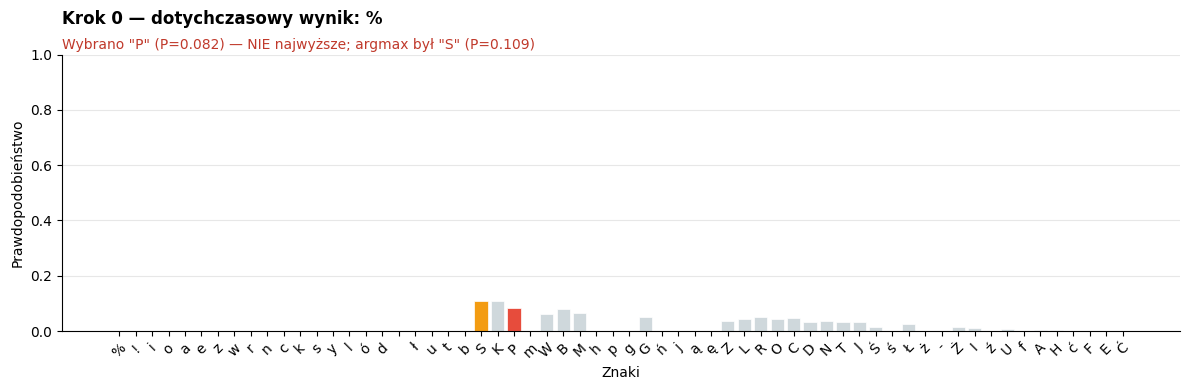

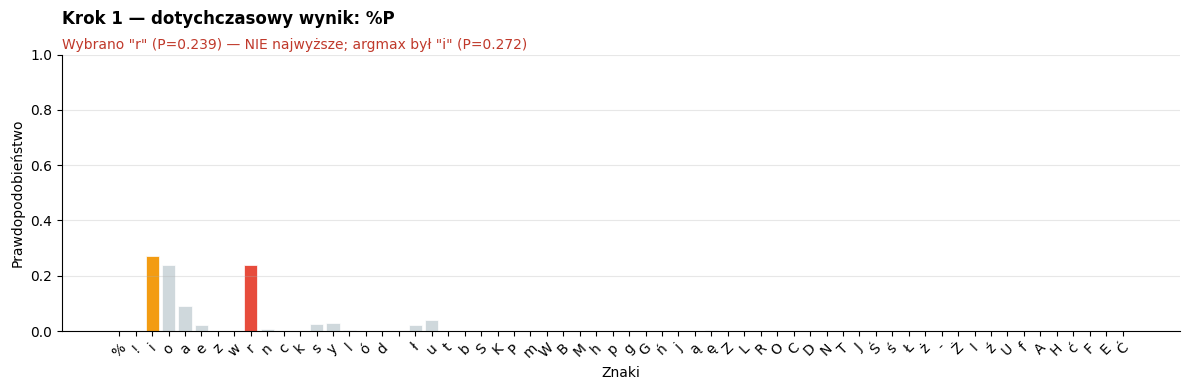

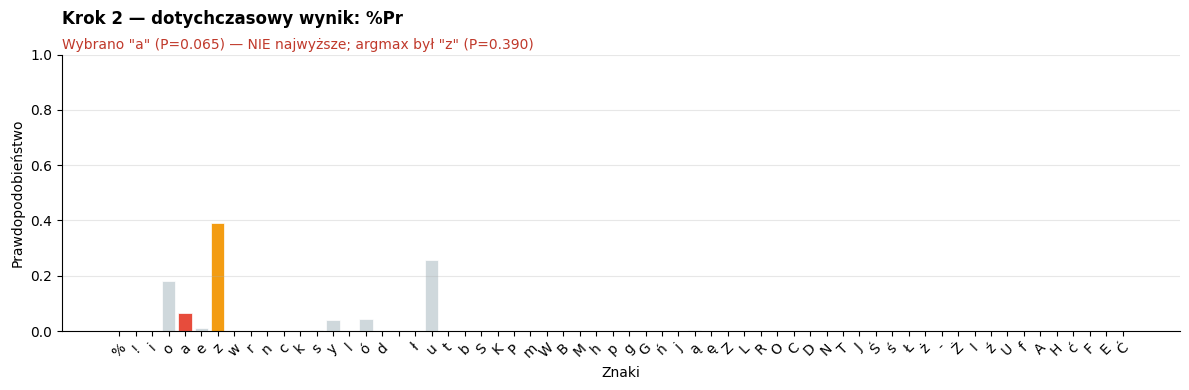

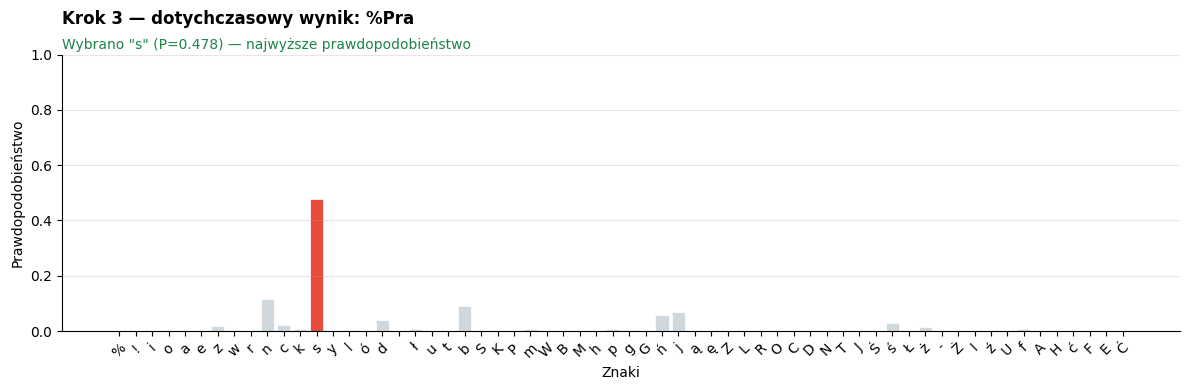

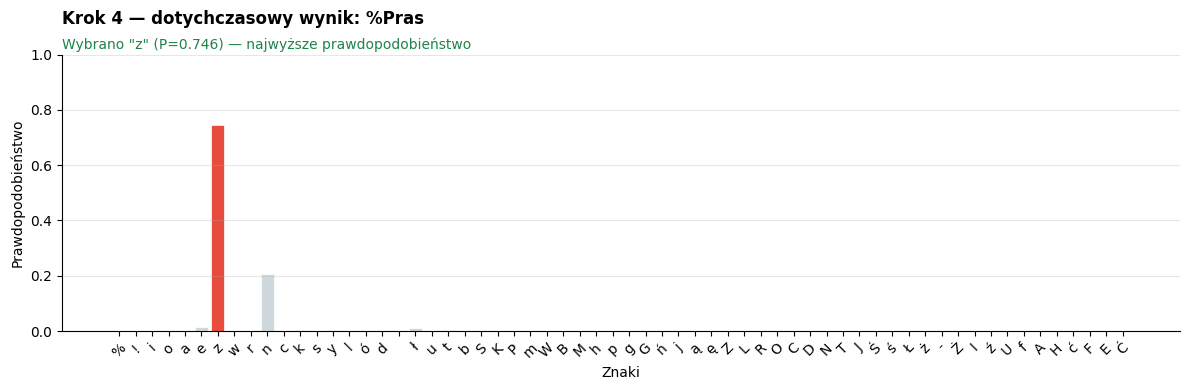

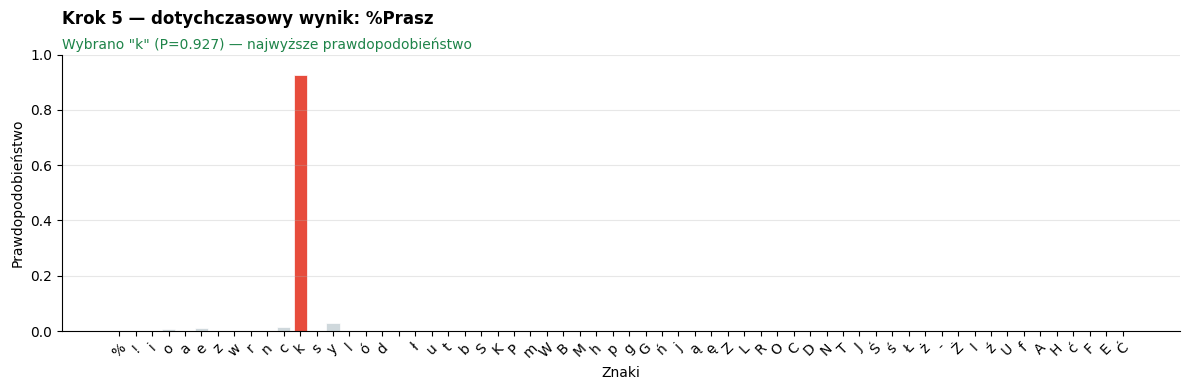

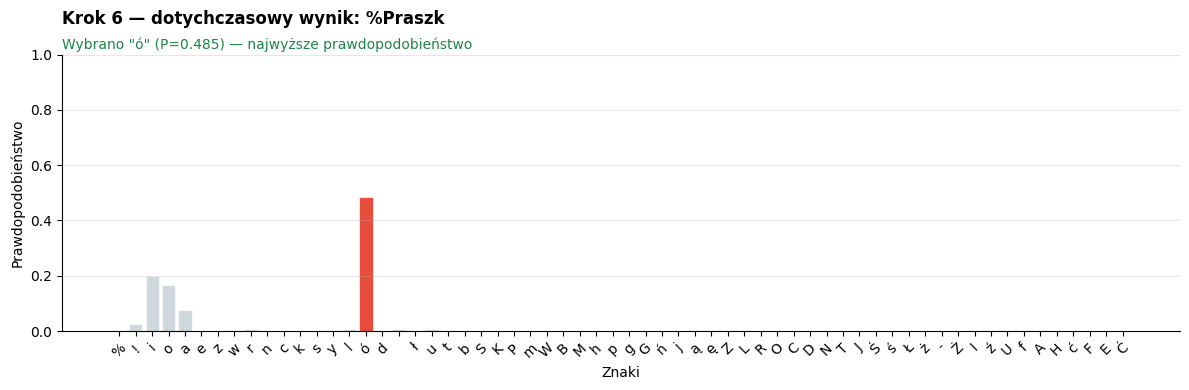

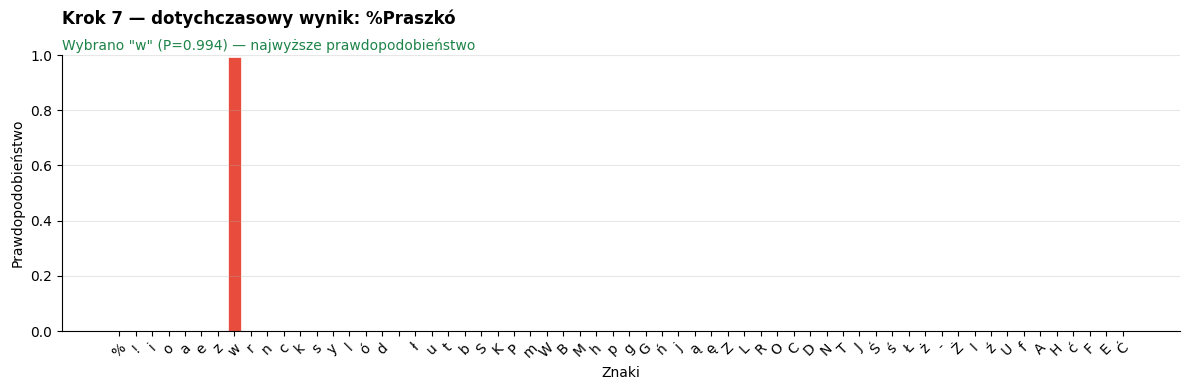

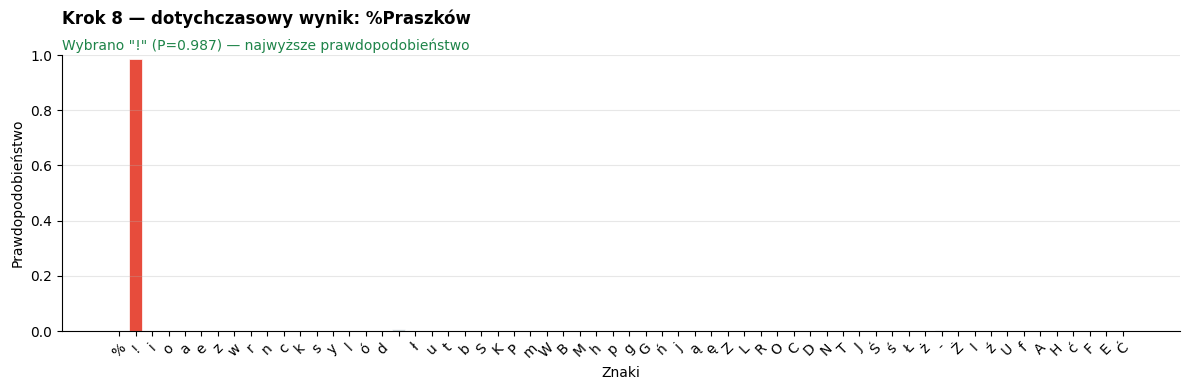

%Praszków!


In [31]:
# Spróbuj różnych promptów — np. "%", "%Wro", "%Adam", "%Łódź" itp.
# Bez `reset_seed` tutaj świadomie — chcemy żeby kolejne wywołania dały różne wyniki.
prompt = '%'
print(sample_model_optimal(prompt, visuals=True, greedy=False, real_cities=set(list_of_cities)))

Powyżej widzisz **wykres rozkładu prawdopodobieństw w każdym kroku** generacji. Zwróć uwagę na kilka rzeczy:

- W pierwszych krokach rozkład jest skupiony na **literach typowych dla początków polskich nazw** (m.in. spacje rzadko, `-` rzadko).
- Im dłuższy prefix, tym **bardziej zdecydowany** rozkład — model "wie" gdzie zmierza nazwa.
- W ostatnim kroku często prawdopodobieństwo **`!` (koniec nazwy)** dominuje — model nauczył się gdzie nazwy kończą się statystycznie.

Niektóre wygenerowane nazwy mogą brzmieć całkiem wiarygodnie (Wadowiczówka, Kamilanów), inne być losowym szumem. Zwróć uwagę jak **nietrywialne jest zagadnienie ewaluacji takiego modelu** — proste metryki jak accuracy czy F1 nie mają tu zastosowania, bo nie ma jednej "poprawnej odpowiedzi".

### Zadanie 5 — porównaj greedy vs stochastic sampling

Dwie strategie próbkowania mają bardzo różne właściwości — sprawdź to empirycznie.

Wygeneruj **20 nazw** używając `sample_model_optimal` w trybie `greedy=True` (bez wizualizacji, bez printowania) oraz osobno **20 nazw** w trybie `greedy=False` (stochastycznie). Wszystkie startujące z prompta `"%"`.

Następnie:
1. Policz **ile unikalnych nazw** jest w każdym zbiorze.
2. Wypisz wyniki.

Co spodziewasz się zobaczyć? Zastanów się **dlaczego** greedy zawsze daje to samo, a stochastic — różne nazwy.

In [24]:
# Tutaj wpisz swój kod

###### <span style="color: #c17f24;">💡 Podpowiedź</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

Liczbę unikalnych elementów w liście można policzyć przez `len(set(lista))`.

Funkcja `sample_model_optimal` zwraca prompt z dołączonym wynikiem — możesz zbierać jej wyniki do listy.

Pamiętaj o flagach `print_outcome=False` i `visuals=False` żeby nie zaśmiecać outputu.

###### <span style="color: #5a8a6a;">✅ Rozwiązanie</span> <span style="color: #999; font-weight: normal; font-size: 0.85em;">(kliknij aby rozwinąć)</span>

In [25]:
reset_seed(SEED)

greedy_names = [sample_model_optimal("%", greedy=True, print_outcome=False) for _ in range(20)]
stochastic_names = [sample_model_optimal("%", greedy=False, print_outcome=False) for _ in range(20)]

print(f"Greedy:     {len(set(greedy_names))} unikalnych z 20")
print(f"Stochastic: {len(set(stochastic_names))} unikalnych z 20")

print("\nPrzykładowe nazwy greedy:")
for name in greedy_names[:5]:
    print(f"  {name[1:-1]}")

print("\nPrzykładowe nazwy stochastic:")
for name in stochastic_names[:5]:
    print(f"  {name[1:-1]}")

Greedy:     1 unikalnych z 20
Stochastic: 20 unikalnych z 20

Przykładowe nazwy greedy:
  Strzelce Krajeńskie
  Strzelce Krajeńskie
  Strzelce Krajeńskie
  Strzelce Krajeńskie
  Strzelce Krajeńskie

Przykładowe nazwy stochastic:
  Budzin
  Tyczyn
  Koniec
  Kosczew
  Sławól


###### 

**Wnioski:**

- **Greedy zawsze daje 1 unikalną nazwę** z 20. Dlaczego? Bo model jest deterministyczny — przy tym samym wejściu zawsze wypluje ten sam rozkład, a `argmax` zawsze wybierze tę samą literę. W każdej iteracji.
- **Stochastic daje ~20 unikalnych nazw** (niemal wszystkie różne). Losowanie wprowadza różnorodność — nawet jeśli litera o najwyższym prawdopodobieństwie jest faworyzowana, czasami wybierze się coś innego, co prowadzi do zupełnie innej ścieżki generacji.

To jest **fundamentalny tradeoff** w generatywnych modelach języka:
- Chcesz **deterministyczny, "najbezpieczniejszy" wynik** → greedy (lub temperature=0 w API LLM).
- Chcesz **różnorodność i kreatywność** → stochastic (lub temperature>0).

W ChatGPT i innych LLM-ach domyślnie używana jest wersja stochastyczna — dlatego za każdym razem dostajesz inną odpowiedź na to samo pytanie. Parametr **temperature** kontroluje balans: niższa = bardziej zachowawczo (bliżej greedy), wyższa = bardziej kreatywnie (bardziej losowo).

###### 

## Od polskich miast do ChatGPT — co dalej?

Zbudowaliśmy malutki model języka generujący nazwy miast. **Cel funkcyjny tego modelu jest dokładnie taki sam jak w GPT-4, Claude czy Gemini** — predykcja kolejnego tokena. Co więc dzieli naszą zabawkę od ChatGPT? Trzy rzeczy: **architektura, skala i dodatkowy trening**.

### 1. Architektura — od GRU do Transformera

Nasz model używa **GRU** — wariantu RNN, który przetwarza tokeny po kolei. Ma to fundamentalne ograniczenia:
- *Vanishing gradient* — sieć słabo pamięta odległy kontekst.
- Sekwencyjne przetwarzanie nie zrównolegla się — wolny trening.

Wszystkie współczesne LLM-y używają **Transformera** z mechanizmem **self-attention**. Każdy token "patrzy na wszystkie inne tokeny w kontekście jednocześnie" — bez sekwencyjności, w pełni równolegle. To pozwala obsłużyć ogromne okna kontekstu (setki tysięcy tokenów) i jest podstawą dzisiejszej rewolucji LLM.

### 2. Skala — od kilobajtów do petabajtów

| | Nasz model | GPT-4 / Claude / Gemini |
|---|---|---|
| Dane | ~1000 nazw miast (~kilka KB) | "Common Crawl" + książki + kod (TB-PB) |
| Parametry | ~50 tys. | setki miliardów / biliony |
| Czas treningu | minuty na laptopie | tygodnie na tysiącach GPU |

### 3. Trening to dopiero początek — Base Model to nie ChatGPT

To jest najmniej oczywisty, ale fascynujący punkt. Po zwykłym treningu na predykcji następnego tokena dostajesz **Base Model** — *symulator dokumentów internetu*. Jeśli zaczniesz dokument o fizyce kwantowej, dokończy go jak naukowiec. Jeśli zaczniesz jak płaskoziemca, dokończy jak płaskoziemca. **Nie wie, że jest asystentem.** Po prostu kontynuuje to co dostał.

Żeby z Base Modelu zrobić ChatGPT, dokłada się dwa dodatkowe etapy:

**a) Supervised Fine-Tuning (SFT)** — bierzemy gotowy Base Model i dokrótkamy go (parę godzin treningu zamiast miesięcy) na **starannie napisanych ręcznie konwersacjach** (~100 tys. dialogów typu "pytanie → idealna odpowiedź asystenta"). Model uczy się **persony pomocnego asystenta** — formy konwersacji, nie nowej wiedzy. Pojawiają się też **tokeny specjalne** typu `<|im_start|>` które działają jak "instrukcje sceniczne" mówiące modelowi: *teraz przestań być internetem, zacznij być asystentem*.

**b) Reinforcement Learning (RLHF)** — model generuje wiele odpowiedzi, a my (lub ludzie-anotatorzy) **rankujemy je**, mówiąc "ta lepsza, tamta gorsza". Z rankingu uczymy osobną sieć — **Reward Model** — która ocenia odpowiedzi. Następnie głównym modelem trenujemy z gradientem od Reward Modelu. Tak uczy się **subtelnego dopasowania** do oczekiwań ludzi: ton, uprzejmość, długość, brak halucynacji.

W zadaniach z weryfikowalnym wynikiem (matematyka, kod) RL działa nawet bez ludzi — wystarczy automatyczna nagroda za "odpowiedź się zgadza".

### 4. Reasoning — modele które "myślą"

Najnowsze LLM-y (o1, DeepSeek R1, Claude 3.5 Sonnet z thinking) potrafią **"myśleć przed odpowiedzią"** — generują wewnętrzny *Chain of Thought* zanim podadzą wynik. Mechanicznie to jest kontynuacja predykcji tokenów — ale w specjalnym bloku `<|thought|>` model "rozmyśla na głos". To odkryto przypadkowo w trakcie RL: model zauważył, że gdy "przypomni sobie zasadę zanim odpowie", częściej trafia w prawidłową odpowiedź — i nauczył się to robić systematycznie.

### Wnioski

Ten malutki notebook pokazał Ci **rdzeń tej samej technologii**, która stoi za ChatGPT:
- Model uczy się **rozkładu warunkowego** kolejnego tokena.
- Generuje sekwencyjnie, **token po tokenie**, z wyborem strategii samplingu.
- Hidden state (u nas GRU, w LLM-ach KV cache) optymalizuje generację.

Przeskalowanie tego do biliona parametrów + dodanie SFT/RLHF + zamiana RNN na Transformer to droga od *"%Kamilocteryx"* do *"Możesz mi wyjaśnić teorię względności jak pięciolatkowi?"*. Reszta to inżynieria, dane i pieniądze — ale **fundament jest dokładnie ten, który właśnie zaimplementowałeś**.

---

## 🚧 ROBOCZO — porównanie konfiguracji modelu (do skasowania przed oddaniem studentom)

Trzy metryki:
- **`val_loss`** — Cross-Entropy na 10% odłożonych prawdziwych nazw (proxy: czy model "rozumie" Polski)
- **`novelty`** — % wygenerowanych nazw spoza training setu (czy nie kopiuje?)
- **`polish_score`** — % trigramów w wygenerowanej nazwie które występują w prawdziwych miastach (czy brzmi po polsku?)

Best params z Optuna search: `emb=256, gru=128, drop=0.1, lr=0.00069, bs=64`. Sprawdzamy też mniejsze alternatywy.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dropout

# Train/val split 90/10 — taki sam jak w lm_search_bayesian.py (seed=42)
reset_seed(SEED)
_idx = np.arange(len(X_train))
np.random.shuffle(_idx)
_split = int(0.9 * len(X_train))
_X_tr, _X_v = X_train[_idx[:_split]], X_train[_idx[_split:]]
_y_tr, _y_v = y_train[_idx[:_split]], y_train[_idx[_split:]]

# Trigramy z prawdziwych miast — referencja dla polish_score
_real_trigrams = set(t for c in list_of_cities for t in zip(c, c[1:], c[2:]))
_city_set = set(list_of_cities)


def polish_score(name):
    """% trigramów występujących w prawdziwych miastach. ~0.85+ → brzmi po polsku."""
    tris = list(zip(name, name[1:], name[2:]))
    if not tris:
        return 0.0
    return sum(1 for t in tris if t in _real_trigrams) / len(tris)


def evaluate_config(emb_dim, gru_units, dropout, lr, max_epochs, batch_size, label, n_gru_layers=1, n_samples=100):
    """Trenuje model z danymi hyperparam i zwraca val_loss, novelty, polish_score + 100 wygenerowanych nazw.

    n_gru_layers — 1 (domyślnie) lub 2 (stacked GRU).
    """
    reset_seed(SEED)

    class LM(keras.Model):
        def __init__(self):
            super().__init__()
            self.embedding = Embedding(vocab_size, emb_dim, mask_zero=True)
            self.gru_stack = [
                GRU(gru_units, return_sequences=True, return_state=True, dropout=dropout)
                for _ in range(n_gru_layers)
            ]
            self.fc = Dense(vocab_size, activation='softmax')
        def call(self, inputs, training=False, hidden_state=None, return_state=False):
            x = self.embedding(inputs, training=training)
            new_states = []
            for i, gru in enumerate(self.gru_stack):
                init = hidden_state[i] if hidden_state is not None else None
                x, st = gru(x, training=training, initial_state=init)
                new_states.append(st)
            x = self.fc(x)
            if return_state:
                return x, new_states
            return x

    m = LM()
    m.compile(loss=SparseCategoricalCrossentropy(), optimizer=keras.optimizers.Adam(lr))
    es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    h = m.fit(_X_tr, _y_tr, validation_data=(_X_v, _y_v),
              epochs=max_epochs, batch_size=batch_size,
              callbacks=[es], verbose=0)

    val_loss = float(min(h.history['val_loss']))
    epochs_used = len(h.history['loss'])

    # Generowanie n_samples nazw — stochastic z propagacją hidden state per warstwa
    reset_seed(SEED)
    names = []
    for _ in range(n_samples):
        encoded = tf.convert_to_tensor(tokenizer.texts_to_sequences(['%']))
        state = None
        out = []
        for _ in range(30):
            logits, state = m(encoded, return_state=True, hidden_state=state)
            probs = logits[0, -1, :].numpy()
            probs = np.clip(probs, 1e-12, 1.0)
            probs /= probs.sum()
            idx = int(np.random.choice(len(probs), p=probs))
            ch = tokenizer.index_word.get(idx)
            if ch is None or ch == '!':
                break
            out.append(ch)
            encoded = tf.convert_to_tensor(tokenizer.texts_to_sequences([ch]))
        names.append(''.join(out))

    novelty = sum(1 for n in names if n not in _city_set) / n_samples
    unique = len(set(names)) / n_samples
    polish = float(np.mean([polish_score(n) for n in names]))
    n_params = m.count_params()

    print(f'=== {label} ===')
    print(f'  config: emb={emb_dim} gru={gru_units}x{n_gru_layers} drop={dropout:.1f} lr={lr} bs={batch_size}')
    print(f'  params: {n_params:,} | epochs_used: {epochs_used} | val_loss: {val_loss:.4f}')
    print(f'  novelty: {novelty:.2f} | unique: {unique:.2f} | polish_score: {polish:.3f}')
    print(f'  sample: {", ".join(names[:8])}')
    print()
    return {'model': m, 'names': names, 'val_loss': val_loss, 'novelty': novelty, 'polish_score': polish, 'params': n_params}

In [ ]:
# Porównanie konfiguracji — od najmniejszej do największej
# Każdy run używa tego samego SEED=42, więc wyniki powinny być identyczne z runem lm_search_bayesian.py

results = {}

# 1. Bardzo mały — trial 9 z search (15k params)
results['XS (trial 9)'] = evaluate_config(
    emb_dim=64, gru_units=32, dropout=0.2, lr=0.0043,
    max_epochs=80, batch_size=16, label='XS (trial 9)')

# 2. Mały — trial 6 (25k params, drop=0.4)
results['S (trial 6)'] = evaluate_config(
    emb_dim=128, gru_units=32, dropout=0.4, lr=0.0019,
    max_epochs=80, batch_size=16, label='S (trial 6)')

# 3. Średni szybki — trial 16 (82k params, lr=0.009)
results['M-fast (trial 16)'] = evaluate_config(
    emb_dim=256, gru_units=64, dropout=0.1, lr=0.0091,
    max_epochs=80, batch_size=64, label='M-fast (trial 16)')

# 4. BEST z search — trial 13 (172k params)
results['L BEST (trial 13)'] = evaluate_config(
    emb_dim=256, gru_units=128, dropout=0.1, lr=0.00069,
    max_epochs=80, batch_size=64, label='L BEST (trial 13)')

# 5. Default oryginalny notebook — emb=128, gru=64, brak dropout, 150 epok
results['DEFAULT'] = evaluate_config(
    emb_dim=128, gru_units=64, dropout=0.0, lr=0.001,
    max_epochs=150, batch_size=32, label='DEFAULT')

# Tabelka podsumowania
print('=' * 70)
print(f'{"label":<22} {"params":>8} {"val_loss":>9} {"novelty":>8} {"polish":>7}')
print('-' * 70)
for label, r in results.items():
    print(f'{label:<22} {r["params"]:>8,} {r["val_loss"]:>9.4f} {r["novelty"]:>8.2f} {r["polish_score"]:>7.3f}')